### インポート

In [1]:
import preprocessing
from train import Trainer
import create_population
from feature_engeneering import PredictionFeatureCreator
from predict import predict
%load_ext autoreload

In [29]:
%autoreload

### 学習母集団の作成
期間を指定すると、学習母集団である(日付、horse_id、race_id)の組を作る

In [16]:
population = create_population.create(
    from_ = "2018-01-01",
    to_ = "2024-12-31"
)

KeyboardInterrupt: 

In [ ]:
population["race_id"].nunique()

22833

In [30]:
df = preprocessing.process_results()

In [31]:
df.head()

,race_id,horse_id,jockey_id,trainer_id,rank_furlongs,rank,wakuban,umaban,sex,age,weight,weight_diff,tansho_odds,popularity,impost,time,time_rank
89888,201701010101,2015101520,663,1127,3.0,4,1,1,0,2,442,-10,31.1,5,54.0,110.1,3.0
89889,201701010101,2015101217,1153,1031,5.0,5,2,2,0,2,472,-18,22.8,4,53.0,111.3,5.0
89885,201701010101,2015100713,1091,1020,2.0,1,3,3,1,2,406,-4,3.0,2,54.0,109.4,1.0
89890,201701010101,2015101689,1151,1035,6.0,6,4,4,0,2,470,-6,82.9,7,53.0,111.9,6.0
89886,201701010101,2015103211,5339,1105,1.0,2,5,5,0,2,484,-4,1.5,1,54.0,109.5,2.0


In [8]:
import pandas as pd

df["time"] = pd.to_datetime(df["タイム"], format = "%M:%S.%f")

In [ ]:
df["time"] = (
    df["time"].dt.minute * 60 + df["time"].dt.second + df["time"].dt.microsecond / 1E6
)

,time,sec
89888,110.1,110.1
89889,111.3,111.3
89885,109.4,109.4
89890,111.9,111.9
89886,109.5,109.5


In [14]:
df["time_rank"] = df.groupby("race_id")["time"].rank(method="min")

In [ ]:
horse_results_preprocessed = preprocessing.process_horse_results()

/home/mech-user/KEI.AI/v3_0_1/src/preprocessing.py:108: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir / "horse_results.csv", sep = "\t").query(


In [ ]:
race_info_preprocesed = preprocessing.process_race_info()

In [ ]:
hose_info_preprocessed = preprocessing.process_horse_info()

### 学習用csvファイルの作成

In [32]:
import feature_engeneering
df  = feature_engeneering.FeatureCreater()
features = df.create_features()

100%|██████████| 5/5 [00:10<00:00,  2.08s/it]


### 学習

In [3]:
from train import Trainer

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 21967, number of negative: 215542
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.134185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54326
[LightGBM] [Info] Number of data points in the train set: 237509, number of used features: 151
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.092489 -> initscore=-2.283614
[LightGBM] [Info] Start training from score -2.283614
Training until validation scores don't improve for 20 rounds
[20]	valid_0's binary_logloss: 0.252246
[40]	valid_0's binary_logloss: 0.243838
[60]	valid_0's binary_logloss: 0.24208
[80]	valid_0's binary_logloss: 0.242074
Early stopping, best iteration is:
[69]	valid_0's binary_logloss: 0.241954
--------------------result--------------------
logloss = 0.20351357512861498


In [4]:
# target
trainer = Trainer(config_filepath="config_new.yaml")
evaluation_df = trainer.run(
    test_start_date="2024-01-01",
    valid_start_date="2023-01-01"
    )

[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Info] Number of positive: 21967, number of negative: 215542
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.133446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54326
[LightGBM] [Info] Number of data points in the train set: 237509, number of used features: 151
[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.092489 -> initscore=-2.283614
[LightGBM] [Info] Start trainin

In [9]:

df = evaluation_df.query("calibrated_pred>0.001")

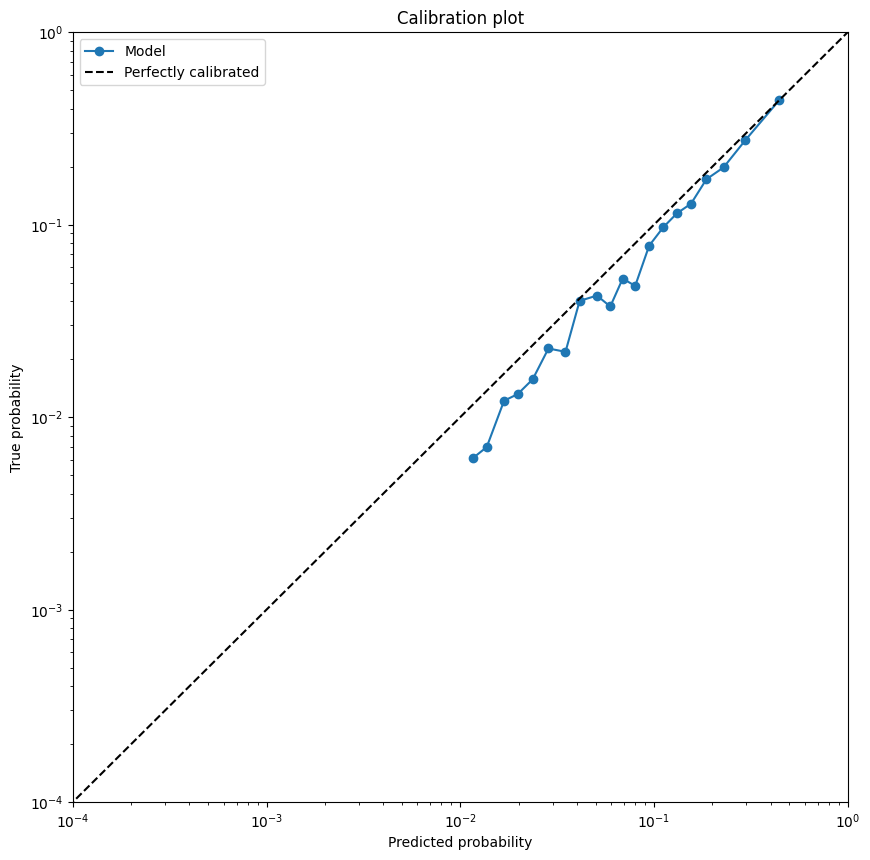

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# 予測確率と実際のターゲット値を使用してキャリブレーションカーブを計算
prob_true, prob_pred = calibration_curve(
    df['target'], df['pred'], n_bins=20, strategy="quantile"
    )

# キャリブレーションプロットを描画
plt.figure(figsize=(10, 10))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0.00001, 1], [0.00001, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlim(0.0001, 1)
plt.ylim(0.0001, 1)
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration plot')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

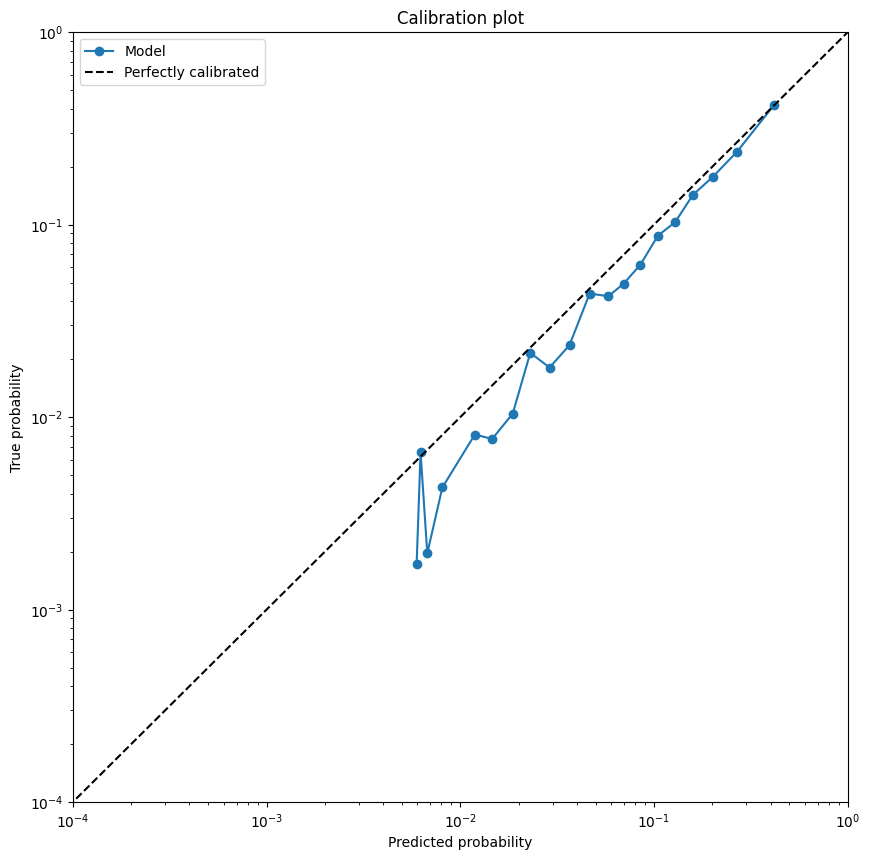

In [13]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# 予測確率と実際のターゲット値を使用してキャリブレーションカーブを計算
prob_true, prob_pred = calibration_curve(
    df['target'], df['pred'], n_bins=20, strategy="quantile"
    )

# キャリブレーションプロットを描画
plt.figure(figsize=(10, 10))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0.00001, 1], [0.00001, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlim(0.0001, 1)
plt.ylim(0.0001, 1)
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration plot')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
import pickle

# calibration.pkl ファイルをロード
calibration_file = trainer.output_dir / "calibration.pkl"
with open(calibration_file, "rb") as f:
    ir = pickle.load(f)

# valid_df に保存された予測値をキャリブレーションする
trainer.df_ir_train["calibrated_pred"] = ir.predict(trainer.df_ir_train["pred"])
df = trainer.df_ir_train


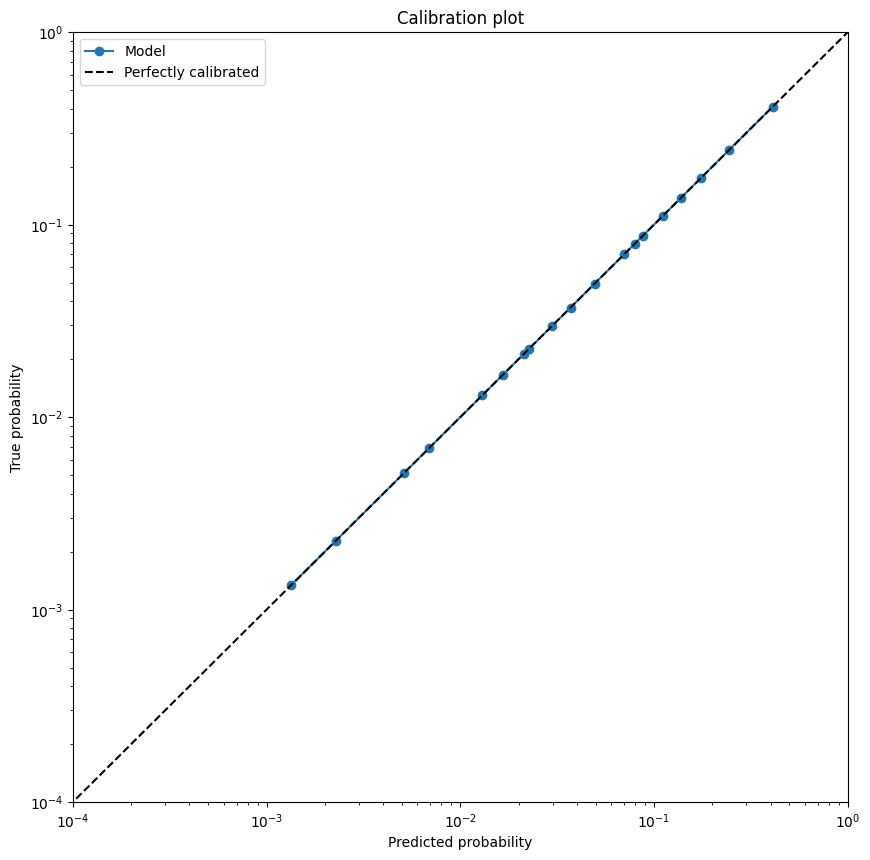

In [9]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# 予測確率と実際のターゲット値を使用してキャリブレーションカーブを計算
prob_true, prob_pred = calibration_curve(
    df['target'], df['calibrated_pred'], n_bins=20, strategy="quantile"
    )

# キャリブレーションプロットを描画
plt.figure(figsize=(10, 10))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0.00001, 1], [0.00001, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlim(0.0001, 1)
plt.ylim(0.0001, 1)
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration plot')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

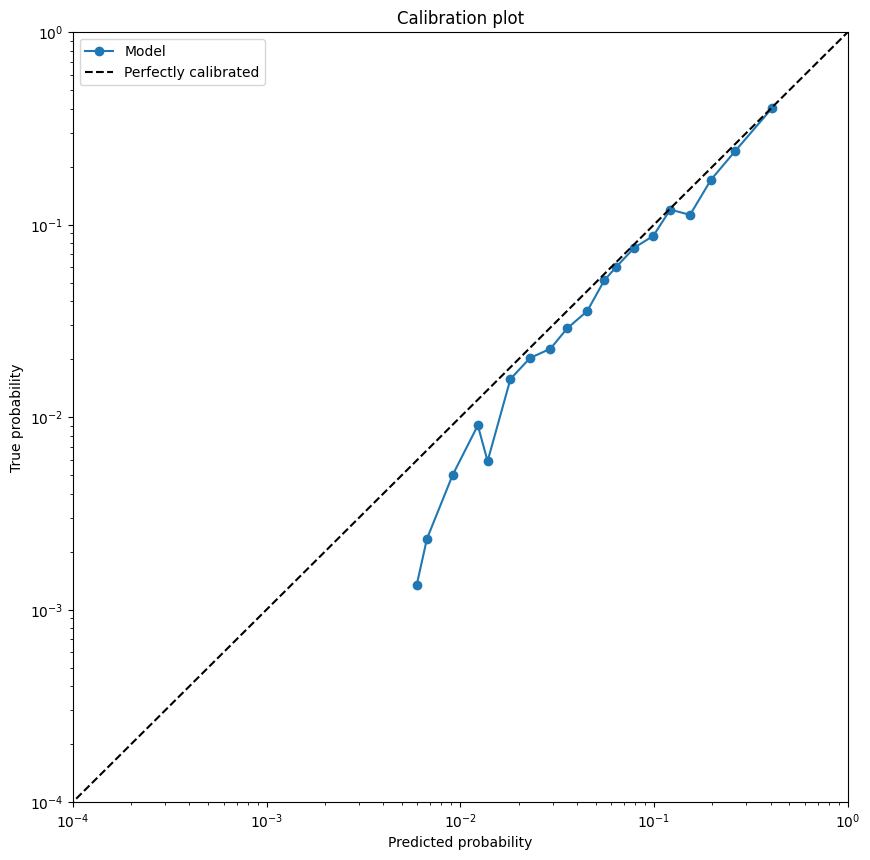

In [8]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# 予測確率と実際のターゲット値を使用してキャリブレーションカーブを計算
prob_true, prob_pred = calibration_curve(
    df['target'], df['pred'], n_bins=20, strategy="quantile"
    )

# キャリブレーションプロットを描画
plt.figure(figsize=(10, 10))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0.00001, 1], [0.00001, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlim(0.0001, 1)
plt.ylim(0.0001, 1)
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration plot')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

In [2]:
# target_mod
trainer = Trainer(config_filepath="config_new.yaml")
evaluation_df = trainer.run(test_start_date="2024-01-01")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 26288, number of negative: 258494
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.405895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 55575
[LightGBM] [Info] Number of data points in the train set: 284782, number of used features: 151
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.092309 -> initscore=-2.285760
[LightGBM] [Info] Start training from score -2.285760
Training until validation scores don't improve for 20 rounds
[5]	training's binary_logloss: 0.275907	valid_1's binary_logloss: 0.26706
[10]	training's binary_logloss: 0.260628	valid_1's binary_logloss: 0.252

a = 10
的中率 = 0.34236804564907275
回収率 = 0.8991440798858774

a = 11
的中率 = 0.34236804564907275
回収率 = 0.8991440798858774

a = 12
的中率 = 0.34759866856871136
回収率 = 0.9069424631478841

a = 13
的中率 = 0.3461721350451736
回収率 = 0.8986210175939134

a = 14
的中率 = 0.34950071326676174
回収率 = 0.8941036614360438

a = 12 が適切と判断

制限なし
的中率 = 0.34759866856871136
回収率 = 0.906942463147884

オッズ>200は無視
的中率 = 0.3514027579648122
回収率 = 0.9194484070375654

オッズ>180は無視
的中率 = 0.3514027579648122
回収率 = 0.9194484070375654

オッズ>160は無視
的中率 = 0.3514027579648122
回収率 = 0.9194484070375654

オッズ>140は無視
的中率 = 0.3514027579648122
回収率 = 0.9194484070375655

オッズ>120は無視
的中率 = 0.3518782691393248
回収率 = 0.9209224916785543

オッズ>100は無視
的中率 = 0.35282929148834996
回収率 = 0.9237280076081787

オッズ>80は無視
的中率 = 0.35235378031383735
回収率 = 0.8766524013314313

ビタどめは良くないので200を採用

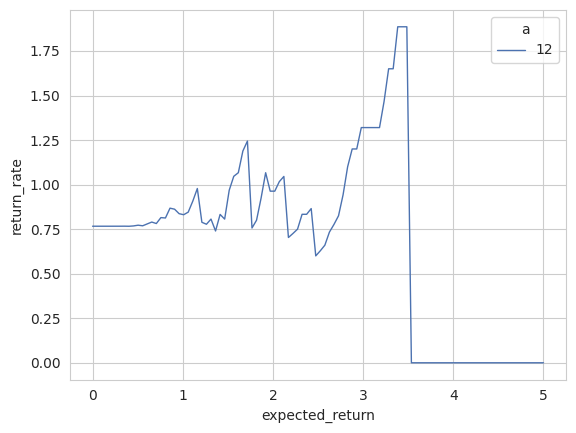

In [3]:
# 普通の期待値でやる
import improve_pred
df = improve_pred.plot()

In [ ]:
len(df[df["expected_value"]>1.6])

84

普通の期待値でやると賭けれる馬の数が年間約3500レースに対して少なすぎるし、旨味も少ない

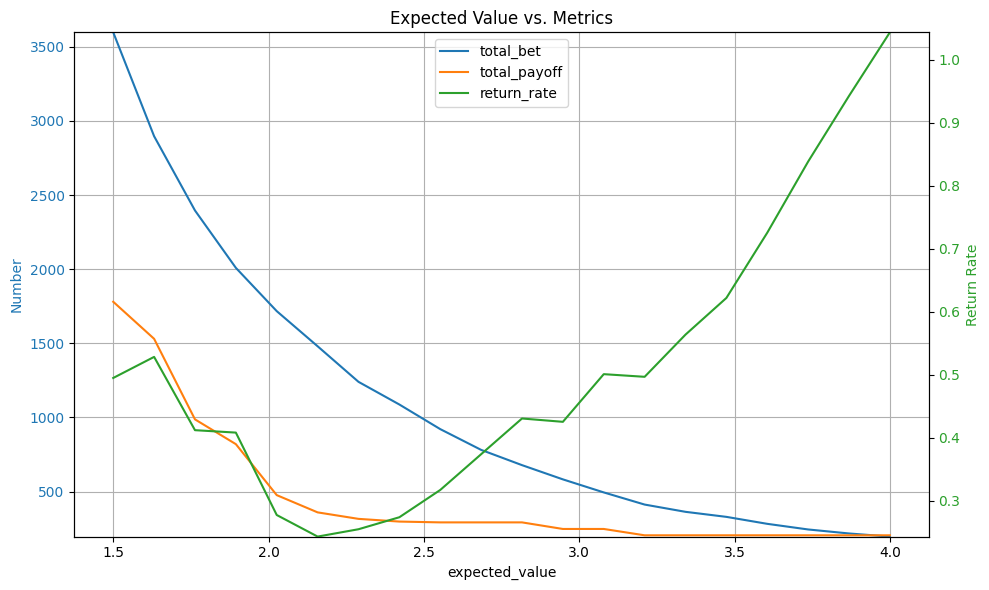

In [1]:
# predのスレッシュホールドなし
import check_pred

df = check_pred.check(min_value=1.5, max_value=4.0)

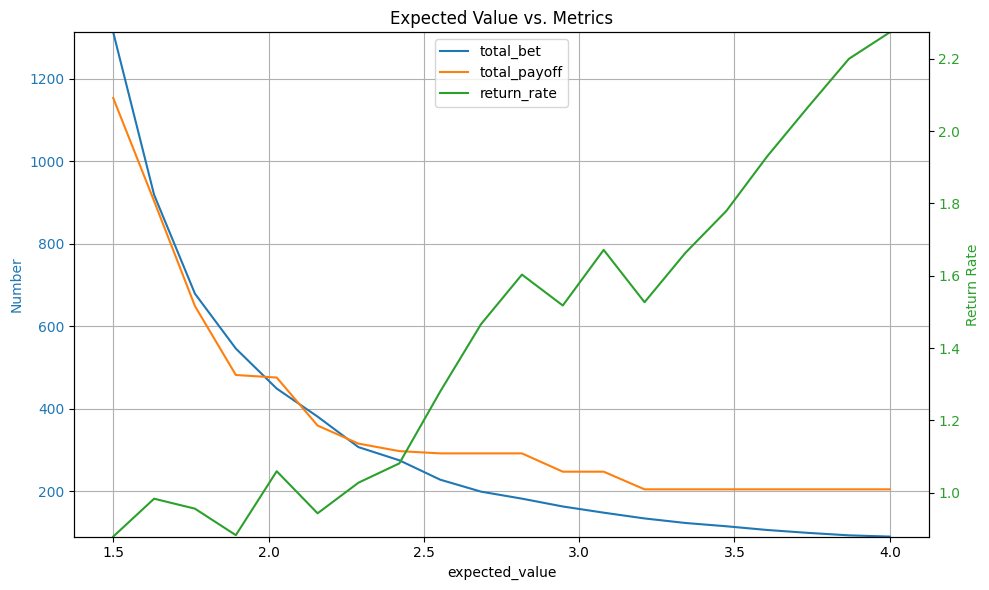

In [1]:
# predのスレッシュホールドあり、0.01
import check_pred

df = check_pred.check(min_value=1.5, max_value=4.0)

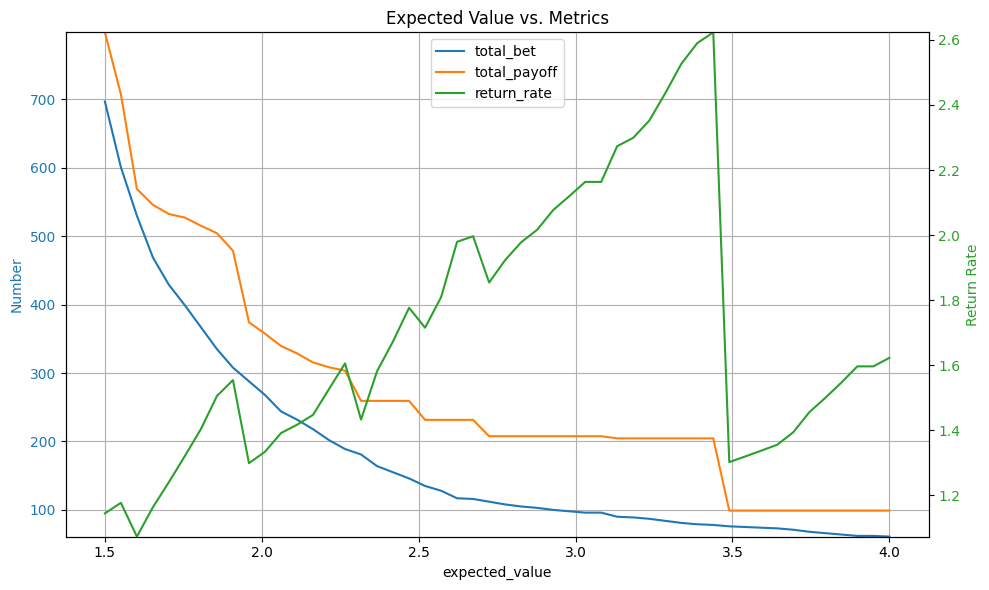

In [1]:
# calibrated_predのスレッシュホールドあり、0.01
import check_pred

df = check_pred.check(min_value=1.5, max_value=4.0)

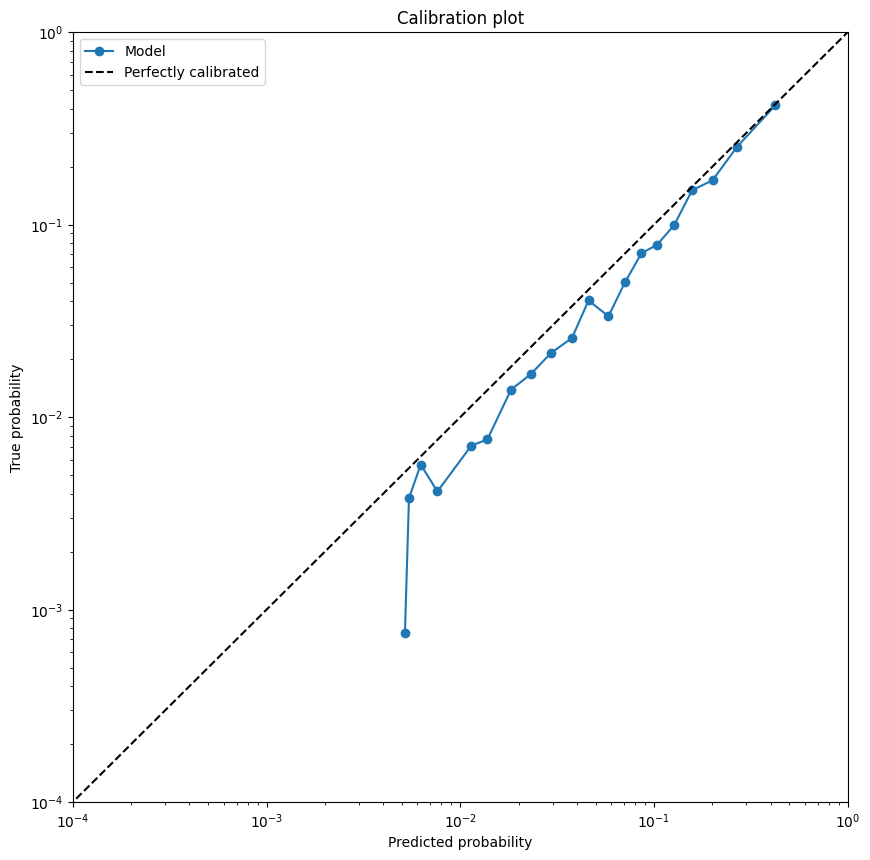

In [4]:
# target_mod変更時のキャリブレーション直線
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

path = Path("..", "data", "03_models", "evaluation.csv")
df = pd.read_csv(path, sep="\t")
# 予測確率と実際のターゲット値を使用してキャリブレーションカーブを計算
prob_true, prob_pred = calibration_curve(
    df['target'], df['pred'], n_bins=20, strategy="quantile"
    )

# キャリブレーションプロットを描画
plt.figure(figsize=(10, 10))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0.00001, 1], [0.00001, 1], linestyle='--', color='black', label='Perfectly calibrated')
plt.xlim(0.0001, 1)
plt.ylim(0.0001, 1)
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration plot')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()


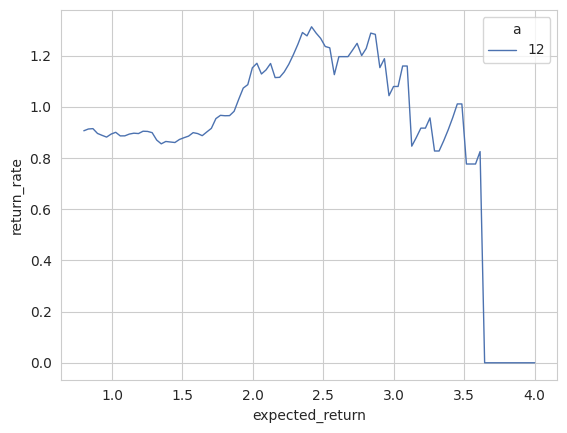

In [ ]:
# 閾値15,期待値はそのまま使う(target_modの前)
import improve_pred
df = improve_pred.plot()

In [9]:
# 閾値2.3のときの年間賭けれる回数、的中率
print(len(df[df["expected_value"]>2.3]))
print(df[df["expected_value"]>2.3]["target"].sum()/len(df[df["expected_value"]>2.3]))

89
0.2808988764044944


In [ ]:
# 閾値2.0のときの年間賭けれる回数、的中率
print(len(df[df["expected_value"]>2.0]))
print(df[df["expected_value"]>2.0]["target"].sum()/len(df[df["expected_value"]>2.0]))

177
0.3107344632768362


期待値約1.2かつ頭数も比較的多いので期待値の閾値は2.0を採用

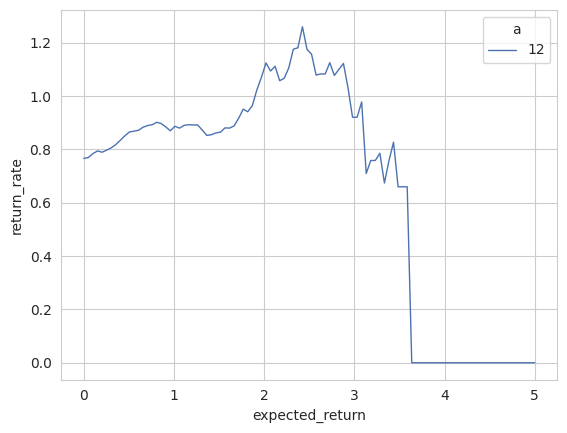

In [ ]:
# 閾値20
import improve_pred
df = improve_pred.plot()

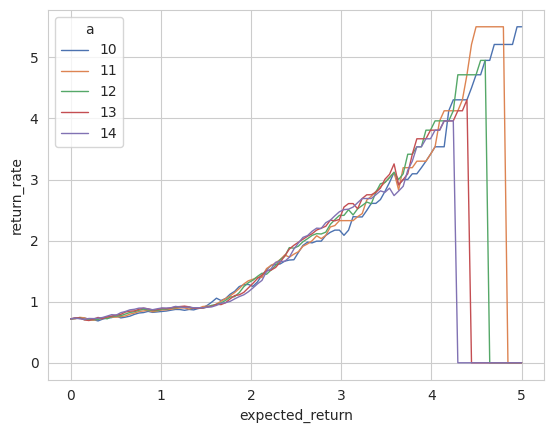

In [1]:
import improve_pred
improve_pred.plot()


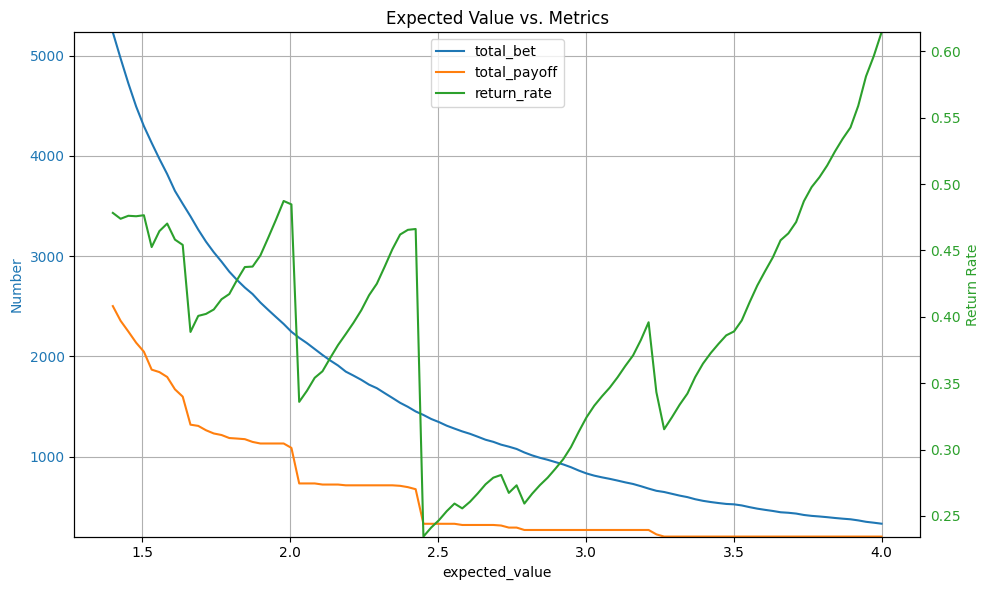

In [2]:
import improve_pred
improve_pred.num_horse_check()

## 実際に予想してみる

In [2]:
horse_results_preprocessed = preprocessing.process_horse_results(
    save_filename="horse_results_prediction.csv"
)

/home/mech-user/KEI.AI/v3_0_1/src/preprocessing.py:108: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir / "horse_results.csv", sep = "\t").query(


In [ ]:
horse_results_preprocessed

,horse_id,date,rank,prize,rank_diff,weather,race_type,course_len,ground_state,race_class,n_horses
0,2021100561,2024-12-15,1.0,1877.1,0.0,0.0,0,1800,0.0,4.0,16.0
1,2021100561,2024-09-29,2.0,749.4,0.2,1.0,0,1800,1.0,4.0,15.0
2,2021100561,2024-09-01,1.0,1586.4,0.0,0.0,0,1800,0.0,5.0,15.0
3,2021100561,2024-08-04,5.0,370.0,0.9,0.0,0,1800,0.0,6.0,15.0
4,2021100561,2024-03-02,1.0,780.0,0.0,1.0,0,1800,1.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...
461690,2015103892,2018-05-19,2.0,200.0,0.1,1.0,1,1400,0.0,1.0,18.0
461691,2015103892,2018-02-03,13.0,0.0,3.9,0.0,0,1400,1.0,1.0,15.0
461692,2015103892,2018-01-20,6.0,0.0,1.0,0.0,0,1400,1.0,1.0,16.0
461693,2015103892,2017-11-11,6.0,0.0,1.0,0.0,1,1400,0.0,1.0,15.0


In [1]:
from feature_engeneering import PredictionFeatureCreator
pfc = PredictionFeatureCreator()

In [2]:
features = pfc.create_features(race_id="202506010111")

100%|██████████| 5/5 [00:00<00:00, 39.76it/s]


shutuba
results


/home/mech-user/KEI.AI/v3_0_1/src/feature_engeneering.py:358: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]


race_info


In [3]:
from predict import predict
predict(features=features, config_filepath="config_new.yaml")

,race_id,umaban,tansho_odds,popularity,pred,new_pred,pred_true,expected_value
14,202506010111,15,4.4,1,0.165599,0.000927,0.269520,1.185888
1,202506010111,2,8.4,4,0.095533,0.000385,0.111991,0.940725
17,202506010111,18,4.6,2,0.138023,0.000677,0.196841,0.905470
2,202506010111,3,11.3,7,0.063367,0.000222,0.064437,0.728140
4,202506010111,5,19.6,9,0.039786,0.000126,0.036579,0.716944
3,202506010111,4,29.8,11,0.025592,0.000076,0.022176,0.660831
6,202506010111,7,10.2,6,0.061638,0.000214,0.062211,0.634552
0,202506010111,1,42.5,12,0.017469,0.000050,0.014640,0.622180
7,202506010111,8,26.0,10,0.026970,0.000081,0.023503,0.611079
13,202506010111,14,8.5,5,0.068694,0.000246,0.071492,0.607682


## 賭け方の理想化

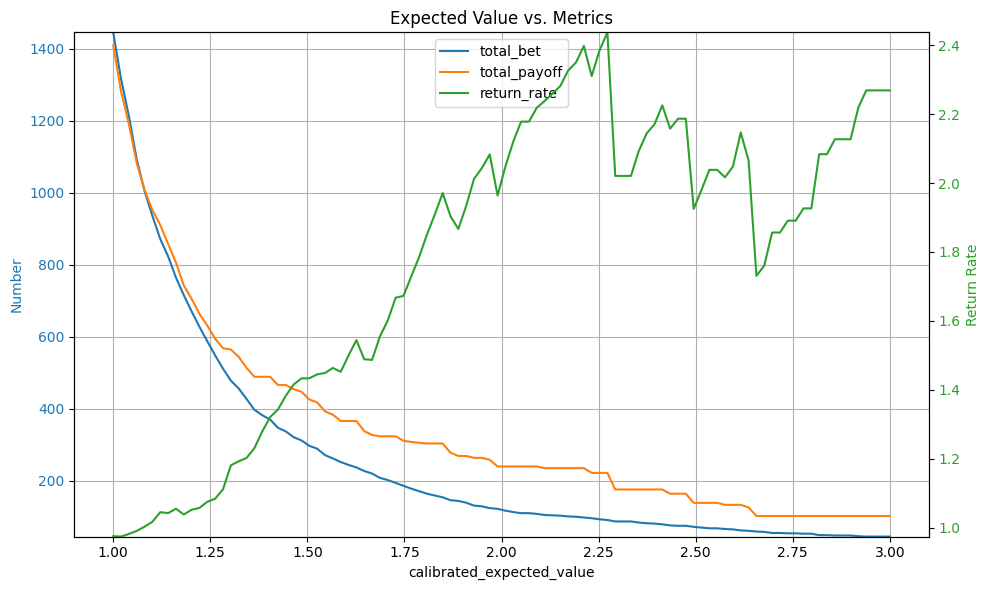

In [3]:
import check_pred

df = check_pred.check(
    min_value = 1.0, 
    max_value = 3.0,
    pred_limit = 0.1,
    odds_limit = 200,
    )

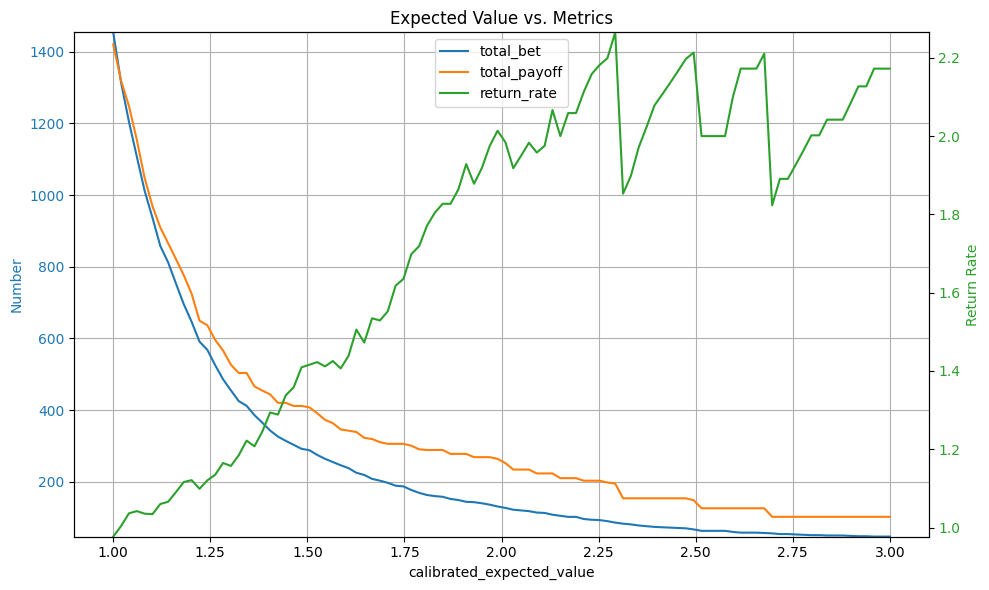

In [33]:
import check_pred

df = check_pred.check(
    min_value = 1.0, 
    max_value = 3.0,
    pred_limit = 0.1,
    odds_limit = 200,
    )

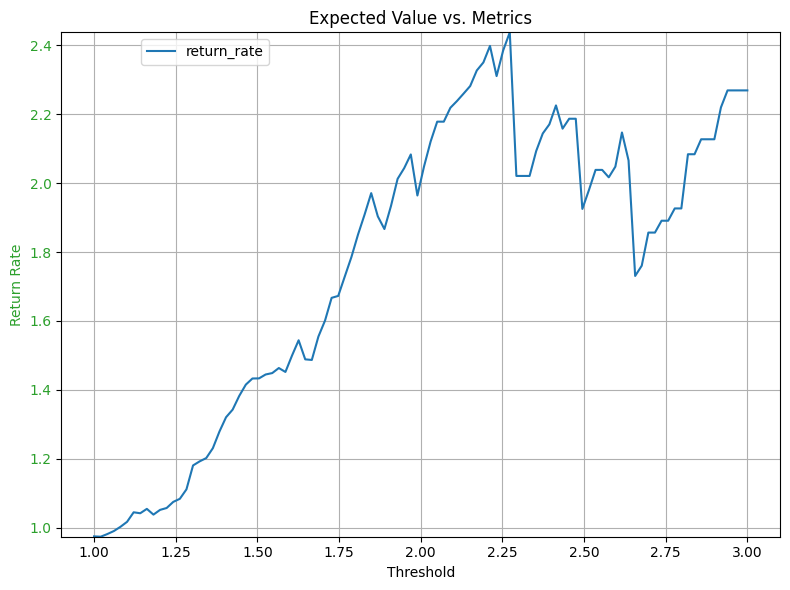

In [1]:
import check_pred

df = check_pred.check_happy(
    min_value = 1.0, 
    max_value = 3.0,
    pred_limit = 0.1,
    odds_limit = 200,
    )

In [ ]:
# optunaのあと
from pathlib import Path
import pandas as pd

INPUT_DIR = Path("..", "data", "03_models", "evaluation.csv")
eva_df = pd.read_csv(INPUT_DIR, sep="\t")

fil_df = eva_df.query(f"calibrated_expected_value>1.5").query(f"calibrated_pred>0.1")#.query(f"tansho_odds<150")

kaisuu = len(fil_df)
atari = fil_df["target"].sum()
rate = atari / kaisuu
fil_df["get"] = fil_df["tansho_odds"]*fil_df["target"]
return_rate = fil_df["get"].sum() / kaisuu
print(f"回数:{kaisuu}, 的中回数:{atari}, 的中率:{rate}, 回収率:{return_rate}")

回数:275, 的中回数:39, 的中率:0.14181818181818182, 回収率:1.1352727272727274


回数:319, 的中回数:45, 的中率:0.14106583072100312, 回収率:1.3987460815047021

In [2]:
from pathlib import Path
import pandas as pd

INPUT_DIR = Path("..", "data", "03_models", "evaluation.csv")
eva_df = pd.read_csv(INPUT_DIR, sep="\t")

fil_df = eva_df.query(f"calibrated_expected_value>1.35").query(f"calibrated_pred>0.1")#.query(f"tansho_odds<90")

kaisuu = len(fil_df)
atari = fil_df["target"].sum()
rate = atari / kaisuu
fil_df["get"] = fil_df["tansho_odds"]*fil_df["target"]
return_rate = fil_df["get"].sum() / kaisuu
print(f"回数:{kaisuu}, 的中回数:{atari}, 的中率:{rate}, 回収率:{return_rate}")

回数:417, 的中回数:57, 的中率:0.1366906474820144, 回収率:1.2004796163069544


In [3]:
print("2024年完成したモデルで賭けた結果")
for start in range(12):
    month_df = fil_df.query(f"month == {start}").copy()
    kaisuu = len(month_df)
    atari = month_df["target"].sum()
    rate = atari / kaisuu
    month_df["get"] = month_df["tansho_odds"]*month_df["target"]
    return_rate = month_df["get"].sum() / kaisuu
    print(f"{start+1}月")
    print(f"回数:{kaisuu}, 的中回数:{atari}, 的中率:{rate:.3f}, 回収率:{return_rate:.3f}")

2024年完成したモデルで賭けた結果
1月
回数:62, 的中回数:11, 的中率:0.177, 回収率:1.198
2月
回数:52, 的中回数:5, 的中率:0.096, 回収率:0.577
3月
回数:48, 的中回数:7, 的中率:0.146, 回収率:1.446
4月
回数:24, 的中回数:3, 的中率:0.125, 回収率:1.000
5月
回数:21, 的中回数:3, 的中率:0.143, 回収率:1.033
6月
回数:34, 的中回数:5, 的中率:0.147, 回収率:0.788
7月
回数:32, 的中回数:4, 的中率:0.125, 回収率:0.637
8月
回数:24, 的中回数:3, 的中率:0.125, 回収率:0.487
9月
回数:41, 的中回数:5, 的中率:0.122, 回収率:0.849
10月
回数:28, 的中回数:6, 的中率:0.214, 回収率:2.168
11月
回数:25, 的中回数:1, 的中率:0.040, 回収率:0.072
12月
回数:26, 的中回数:4, 的中率:0.154, 回収率:4.808


## ハイパーパラメータの調整

In [4]:
from train_optuna import Trainer
trainer = Trainer()
%load_ext autoreload

In [52]:
%autoreload

ハイパラ調整なし<br>
--------------------result--------------------<br>
logloss = 0.20511563419490586

In [53]:
df = trainer.run()

Training until validation scores don't improve for 30 rounds
[5]	valid_0's l2: 0.0781271
[10]	valid_0's l2: 0.0751047
[15]	valid_0's l2: 0.0736675
[20]	valid_0's l2: 0.072478
[25]	valid_0's l2: 0.0717396
[30]	valid_0's l2: 0.0712298
[35]	valid_0's l2: 0.0709361
[40]	valid_0's l2: 0.0707442
[45]	valid_0's l2: 0.07064
[50]	valid_0's l2: 0.0705972
[55]	valid_0's l2: 0.0705463
[60]	valid_0's l2: 0.0705387
[65]	valid_0's l2: 0.0705583
[70]	valid_0's l2: 0.070573
[75]	valid_0's l2: 0.0705793
[80]	valid_0's l2: 0.0706187
[85]	valid_0's l2: 0.0706454
[90]	valid_0's l2: 0.0706929
Early stopping, best iteration is:
[61]	valid_0's l2: 0.070527
--------------------result--------------------
logloss = 0.20516733370270243


--------------------result--------------------
logloss = 0.205206937727651

In [54]:
trainer.best_params

{'learning_rate': 0.05,
 'num_leaves': 41,
 'min_data_in_leaf': 15,
 'feature_fraction': 0.9,
 'bagging_fraction': 1.0,
 'bagging_freq': 7,
 'lamda_l1': 1.0,
 'lamda_l2': 1.0}

In [9]:
trainer.best_params

{'learning_rate': 0.0946,
 'num_leaves': 148,
 'min_data_in_leaf': 10,
 'feature_fraction': 0.458,
 'bagging_fraction': 0.4,
 'bagging_freq': 4}